In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
from deeplabv3p.model import DeepLabV3Plus
from utils.constants import BATCH_SIZE, IMAGE_SIZE
from torchinfo import summary
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model, model_name = DeepLabV3Plus(3, 1), "DeepLabV3p_20102024-160203_dice86.pth"
path = os.path.join("..", 'models', model_name)
model.load_state_dict(torch.load(path, weights_only=True))
model.to(device)
model.eval()
summary(model, input_size=(BATCH_SIZE, 3, *IMAGE_SIZE))

Layer (type:depth-idx)                        Output Shape              Param #
DeepLabV3Plus                                 [8, 1, 256, 256]          --
├─Sequential: 1-1                             [8, 64, 128, 128]         --
│    └─Conv2d: 2-1                            [8, 64, 128, 128]         1,728
│    └─BatchNorm2d: 2-2                       [8, 64, 128, 128]         128
│    └─GELU: 2-3                              [8, 64, 128, 128]         --
├─Sequential: 1-2                             [8, 128, 64, 64]          --
│    └─Conv2d: 2-4                            [8, 128, 64, 64]          73,728
│    └─BatchNorm2d: 2-5                       [8, 128, 64, 64]          256
│    └─GELU: 2-6                              [8, 128, 64, 64]          --
├─Sequential: 1-3                             [8, 256, 32, 32]          --
│    └─Conv2d: 2-7                            [8, 256, 32, 32]          294,912
│    └─BatchNorm2d: 2-8                       [8, 256, 32, 32]          512
│    

In [3]:
from dataset.transforms import get_inference_transforms
from dataset.image_dataset import ImageDataset

dataset = ImageDataset('../data/val', transforms=get_inference_transforms())

def get_img_mask():
    imgs, masks = [], []
    for i in range(4):
        # idx = torch.randint(0, len(dataset), (1,)).item()
        img, mask = dataset[i]
        imgs.append(img.to(device))
        masks.append(mask.to(device))
    return imgs, masks

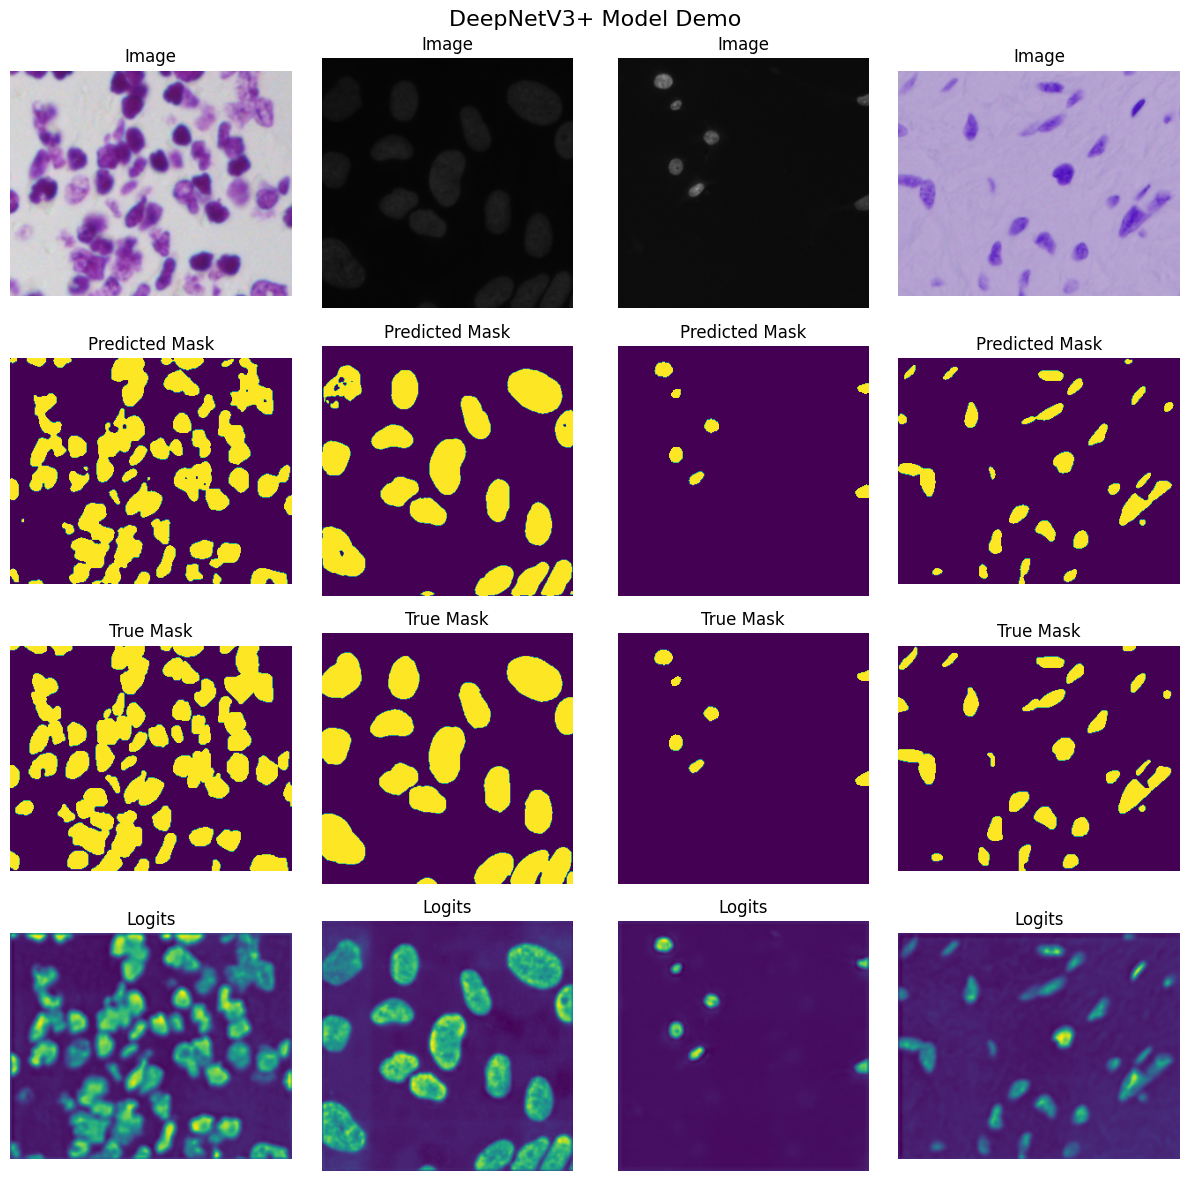

In [4]:
fig, axs = plt.subplots(4, 4, figsize=(12, 12))
imgs, masks = get_img_mask()

fig.suptitle('DeepNetV3+ Model Demo', fontsize=16)

for i in range(4):
    pred_dict = model.predict(imgs[i])    
    pred = pred_dict['pred']
    img = pred_dict['img']
    logits = pred_dict['logits']
    true_mask = masks[i].cpu().numpy().transpose(1, 2, 0)
    
    axs[0, i].imshow(img)
    axs[0, i].axis('off')
    axs[0, i].set_title('Image')
    
    axs[1, i].imshow(pred)
    axs[1, i].axis('off')
    axs[1, i].set_title('Predicted Mask')
    
    axs[2, i].imshow(true_mask)
    axs[2, i].axis('off')
    axs[2, i].set_title('True Mask')
    
    axs[3, i].imshow(logits)
    axs[3, i].axis('off')
    axs[3, i].set_title('Logits')
    
plt.tight_layout()
plt.show()